In [23]:
import pandas as pd
import numpy as np

In [24]:
data = pd.read_csv('../Data/customer_support_tickets.csv')

df = pd.DataFrame(data)
print(df)

      Ticket ID        Customer Name              Customer Email  \
0             1        Marisa Obrien  carrollallison@example.com   
1             2         Jessica Rios    clarkeashley@example.com   
2             3  Christopher Robbins   gonzalestracy@example.com   
3             4     Christina Dillon    bradleyolson@example.org   
4             5    Alexander Carroll     bradleymark@example.com   
...         ...                  ...                         ...   
8464       8465           David Todd          adam28@example.net   
8465       8466           Lori Davis       russell68@example.com   
8466       8467      Michelle Kelley        ashley83@example.org   
8467       8468     Steven Rodriguez         fpowell@example.org   
8468       8469      Steven Davis MD          lori20@example.net   

      Customer Age Customer Gender       Product Purchased Date of Purchase  \
0               32           Other              GoPro Hero       2021-03-22   
1               42       

In [25]:
df.describe()
df.info()
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 8469 entries, 0 to 8468
Data columns (total 17 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Ticket ID                     8469 non-null   int64  
 1   Customer Name                 8469 non-null   str    
 2   Customer Email                8469 non-null   str    
 3   Customer Age                  8469 non-null   int64  
 4   Customer Gender               8469 non-null   str    
 5   Product Purchased             8469 non-null   str    
 6   Date of Purchase              8469 non-null   str    
 7   Ticket Type                   8469 non-null   str    
 8   Ticket Subject                8469 non-null   str    
 9   Ticket Description            8469 non-null   str    
 10  Ticket Status                 8469 non-null   str    
 11  Resolution                    2769 non-null   str    
 12  Ticket Priority               8469 non-null   str    
 13  Ticket Channel

,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating
0,1,Marisa Obrien,carrollallison@example.com,32,Other,GoPro Hero,2021-03-22,Technical issue,Product setup,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Social media,2023-06-01 12:15:36,NaN,NaN
1,2,Jessica Rios,clarkeashley@example.com,42,Female,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Chat,2023-06-01 16:45:38,NaN,NaN
2,3,Christopher Robbins,gonzalestracy@example.com,48,Other,Dell XPS,2020-07-14,Technical issue,Network problem,I'm facing a problem with my {product_purchase...,Closed,Case maybe show recently my computer follow.,Low,Social media,2023-06-01 11:14:38,2023-06-01 18:05:38,3.0
3,4,Christina Dillon,bradleyolson@example.org,27,Female,Microsoft Office,2020-11-13,Billing inquiry,Account access,I'm having an issue with the {product_purchase...,Closed,Try capital clearly never color toward story.,Low,Social media,2023-06-01 07:29:40,2023-06-01 01:57:40,3.0
4,5,Alexander Carroll,bradleymark@example.com,67,Female,Autodesk AutoCAD,2020-02-04,Billing inquiry,Data loss,I'm having an issue with the {product_purchase...,Closed,West decision evidence bit.,Low,Email,2023-06-01 00:12:42,2023-06-01 19:53:42,1.0


In [26]:
df.isnull().sum()

Ticket ID                          0
Customer Name                      0
Customer Email                     0
Customer Age                       0
Customer Gender                    0
Product Purchased                  0
Date of Purchase                   0
Ticket Type                        0
Ticket Subject                     0
Ticket Description                 0
Ticket Status                      0
Resolution                      5700
Ticket Priority                    0
Ticket Channel                     0
First Response Time             2819
Time to Resolution              5700
Customer Satisfaction Rating    5700
dtype: int64

In [27]:
df.drop(columns=['Customer Name', 'Customer Email'], inplace=True)

In [28]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8469 entries, 0 to 8468
Data columns (total 15 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Ticket ID                     8469 non-null   int64  
 1   Customer Age                  8469 non-null   int64  
 2   Customer Gender               8469 non-null   str    
 3   Product Purchased             8469 non-null   str    
 4   Date of Purchase              8469 non-null   str    
 5   Ticket Type                   8469 non-null   str    
 6   Ticket Subject                8469 non-null   str    
 7   Ticket Description            8469 non-null   str    
 8   Ticket Status                 8469 non-null   str    
 9   Resolution                    2769 non-null   str    
 10  Ticket Priority               8469 non-null   str    
 11  Ticket Channel                8469 non-null   str    
 12  First Response Time           5650 non-null   str    
 13  Time to Resolu

In [29]:
print(df[['First Response Time', 'Time to Resolution']].head(10))
print(df.dtypes)

   First Response Time   Time to Resolution
0  2023-06-01 12:15:36                  NaN
1  2023-06-01 16:45:38                  NaN
2  2023-06-01 11:14:38  2023-06-01 18:05:38
3  2023-06-01 07:29:40  2023-06-01 01:57:40
4  2023-06-01 00:12:42  2023-06-01 19:53:42
5                  NaN                  NaN
6                  NaN                  NaN
7                  NaN                  NaN
8  2023-06-01 10:32:47                  NaN
9  2023-06-01 09:25:48                  NaN
Ticket ID                         int64
Customer Age                      int64
Customer Gender                     str
Product Purchased                   str
Date of Purchase                    str
Ticket Type                         str
Ticket Subject                      str
Ticket Description                  str
Ticket Status                       str
Resolution                          str
Ticket Priority                     str
Ticket Channel                      str
First Response Time                 

In [30]:
df = df.rename(columns={
        "Ticket ID": "ticket_id",
        "Customer Age": "customer_age",
        "Customer Gender": "customer_gender",
        "Product Purchased": "product_purchased",
        "Date of Purchase": "date_of_purchase",
        "Ticket Type": "category",
        "Ticket Subject": "subject",
        "Ticket Description": "description",
        "Ticket Status": "status",
        "Resolution": "resolution_notes",
        "Ticket Priority": "priority",
        "Ticket Channel": "channel",
        "First Response Time": "first_response_time",
        "Time to Resolution": "time_to_resolution",
        "Customer Satisfaction Rating": "satisfaction_rating",
    })

In [31]:
df["first_response_time"] = pd.to_datetime(df["first_response_time"], errors="coerce")
df["time_to_resolution"] = pd.to_datetime(df["time_to_resolution"], errors="coerce")
df["date_of_purchase"] = pd.to_datetime(df["date_of_purchase"], errors="coerce")

In [32]:
df.isnull().sum()
df.head()

,ticket_id,customer_age,customer_gender,product_purchased,date_of_purchase,category,subject,description,status,resolution_notes,priority,channel,first_response_time,time_to_resolution,satisfaction_rating
0,1,32,Other,GoPro Hero,2021-03-22,Technical issue,Product setup,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Social media,2023-06-01 12:15:36,NaT,NaN
1,2,42,Female,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Chat,2023-06-01 16:45:38,NaT,NaN
2,3,48,Other,Dell XPS,2020-07-14,Technical issue,Network problem,I'm facing a problem with my {product_purchase...,Closed,Case maybe show recently my computer follow.,Low,Social media,2023-06-01 11:14:38,2023-06-01 18:05:38,3.0
3,4,27,Female,Microsoft Office,2020-11-13,Billing inquiry,Account access,I'm having an issue with the {product_purchase...,Closed,Try capital clearly never color toward story.,Low,Social media,2023-06-01 07:29:40,2023-06-01 01:57:40,3.0
4,5,67,Female,Autodesk AutoCAD,2020-02-04,Billing inquiry,Data loss,I'm having an issue with the {product_purchase...,Closed,West decision evidence bit.,Low,Email,2023-06-01 00:12:42,2023-06-01 19:53:42,1.0


In [33]:
df.loc[(df['status']=='Open')&(df['resolution_notes'].isna()), 'resolution_notes']='Under Investigation'
df.loc[(df['status']=='Pending Customer Response')&(df['resolution_notes'].isna()), 'resolution_notes'] = 'follow up sent'

In [34]:
df.loc[df['status'].isin(['Open', 'Pending Customer Response']), 'satisfaction_rating']= 0 
df['has_rating'] = ~df['status'].isin(['Open', 'Pending Customer Response'])

df['resolution_duration_hours']=(pd.to_datetime(df['time_to_resolution'])-pd.to_datetime(df['first_response_time'])).dt.total_seconds()/3600
df['duration_is_invalid']=df['resolution_duration_hours']<0
df['description_length']=df['description'].str.len()
df.isnull().sum()

ticket_id                       0
customer_age                    0
customer_gender                 0
product_purchased               0
date_of_purchase                0
category                        0
subject                         0
description                     0
status                          0
resolution_notes                0
priority                        0
channel                         0
first_response_time          2819
time_to_resolution           5700
satisfaction_rating             0
has_rating                      0
resolution_duration_hours    5700
duration_is_invalid             0
description_length              0
dtype: int64

In [35]:
df.to_csv('../Data/tickets_clean.csv', index=False)

In [36]:
import matplotlib.pyplot as plt

<Axes: title={'center': ' Ticket Priority Distribution'}, xlabel='priority'>

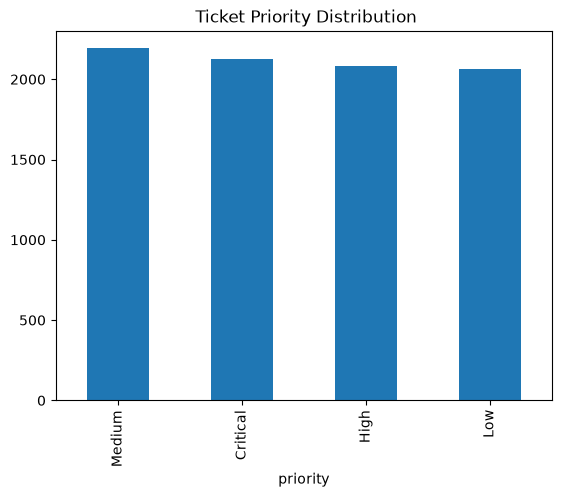

In [37]:
df['priority'].value_counts().plot(kind='bar', title= ' Ticket Priority Distribution')

<Axes: title={'center': 'Ticket Category Distribution'}, xlabel='category'>

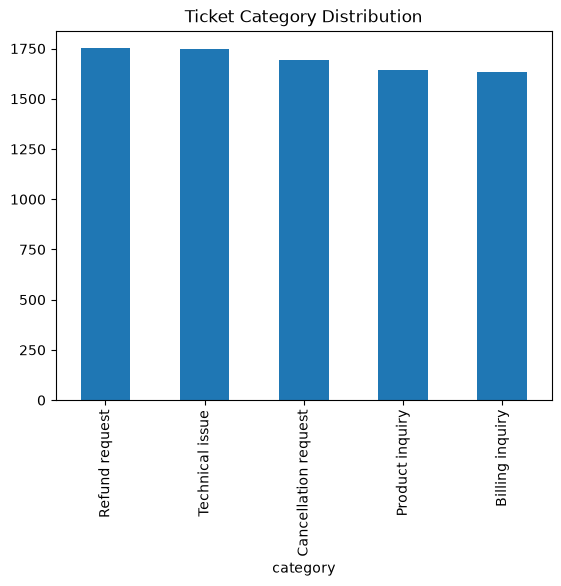

In [38]:
df['category'].value_counts().plot(kind='bar', title='Ticket Category Distribution')

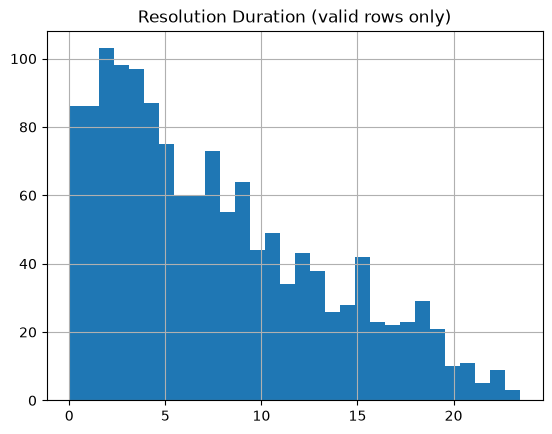

In [39]:
df[df['duration_is_invalid']==False]['resolution_duration_hours'].hist(bins=30)
plt.title('Resolution Duration (valid rows only)')
plt.show()

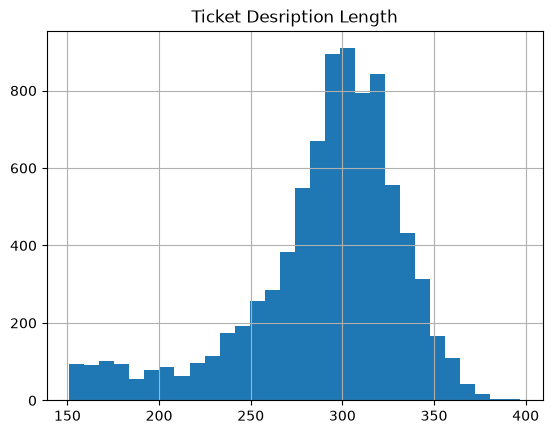

In [40]:
df['description_length'].hist(bins=30)
plt.title('Ticket Desription Length')
plt.show()

In [41]:
print(df['priority'].value_counts(normalize=True))
print(df['category'].value_counts(normalize=True))
print(f"Invalid duration rows: {df['duration_is_invalid'].mean():.1%}")

priority
Medium      0.258826
Critical    0.251387
High        0.246192
Low         0.243594
Name: proportion, dtype: float64
category
Refund request          0.206872
Technical issue         0.206282
Cancellation request    0.200142
Product inquiry         0.193765
Billing inquiry         0.192939
Name: proportion, dtype: float64
Invalid duration rows: 16.1%


In [42]:
print(df[df['duration_is_invalid']]['priority'].value_counts(normalize=True))

priority
Medium      0.258608
Critical    0.257875
High        0.256410
Low         0.227106
Name: proportion, dtype: float64


In [44]:
df['log_resolution_duration'] = np.log1p(df.loc[~df['duration_is_invalid'], 'resolution_duration_hours'])
print(df['log_resolution_duration'].isna().sum())
print(df['duration_is_invalid'].sum())

7065
1365
